In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 兼容各系统的字体设置:
import os
# import platform
# system = platform.system()

# if system == 'Windows':
#     plt.rcParams['font.sans-serif'] = ['SimHei']
#     font_path = 'C:/Windows/Fonts/simhei.ttf'
# elif system == 'Darwin':  # Mac
#     plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'STHeiti']
#     plt.rcParams['font.family'] = 'sans-serif'
#     font_candidates = [
#         '/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc',
#     ]
#     font_path = None
#     for candidate in font_candidates:
#         if os.path.exists(candidate):
#             font_path = candidate
#             break
# else:  # Linux
#     plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']
#     font_path = '/usr/share/fonts/truetype/wqy/wqy-microhei.ttc'

# plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# my_font = fm.FontProperties(fname=font_path) if font_path else None

# 加载数据集并指定编码为gbk
data = pd.read_csv('medical_data.csv', encoding='gbk')

# 查看数据类型
print(data.dtypes)
# 查看表结构基本信息
print(data.info())

# 显示每一列的空缺值数量
print(data.isnull().sum())

# 规范日期格式
data['就诊日期'] = pd.to_datetime(data['就诊日期'])
data['诊断日期'] = pd.to_datetime(data['诊断日期'])

# 修改列名
data.rename(columns={'病人ID': '患者ID'}, inplace=True)

# 查看修改后的表结构
print(data.head())

from datetime import datetime

# 增加诊断延迟和病程列
data['诊断延迟'] = (data['诊断日期'] - data['就诊日期']).dt.days
data['病程'] = (datetime(2024, 9, 1) - data['诊断日期']).dt.days

# 删除不合理的数据
data = data[(data['诊断延迟'] >= 0) & (data['年龄'] > 0) & (data['年龄'] < 120)]

# 查看修改后的数据
print(data.describe())

# 删除重复值并记录删除的行数
initial_rows = data.shape[0]
data.drop_duplicates(inplace=True)
deleted_rows = initial_rows - data.shape[0]

print(f'删除的重复行数: {deleted_rows}')

from sklearn.preprocessing import MinMaxScaler

# 对需要归一化的列进行处理
scaler = MinMaxScaler()
columns_to_normalize = ['年龄', '体重', '身高']
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])

# 查看归一化后的数据
print(data.head())


病人ID        int64
年龄          int64
性别         object
地区         object
就诊日期       object
疾病类型       object
诊断日期       object
疾病严重程度     object
治疗方案       object
治疗结果       object
药物名称       object
药物分类       object
用药剂量       object
用药时长       object
检查项目       object
检查结果      float64
参考范围       object
体重        float64
身高        float64
吸烟情况       object
饮酒情况       object
遗传病史       object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5440 entries, 0 to 5439
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   病人ID    5440 non-null   int64  
 1   年龄      5440 non-null   int64  
 2   性别      5440 non-null   object 
 3   地区      5438 non-null   object 
 4   就诊日期    5439 non-null   object 
 5   疾病类型    5440 non-null   object 
 6   诊断日期    5429 non-null   object 
 7   疾病严重程度  5439 non-null   object 
 8   治疗方案    5438 non-null   object 
 9   治疗结果    5437 non-null   object 
 10  药物名称    5438 non-null   object 
 1

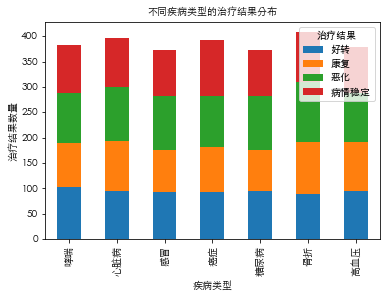

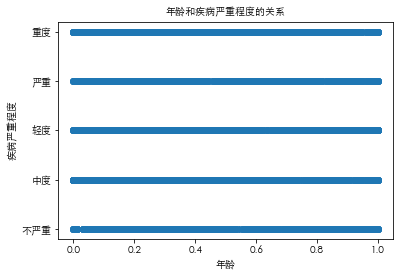

In [7]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 兼容各系统的字体设置:
import os
import platform
system = platform.system()

if system == 'Windows':
    plt.rcParams['font.sans-serif'] = ['SimHei']
elif system == 'Darwin':  # Mac
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
else:  # Linux
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 原始代码（考试环境使用）:
# font_path = 'C:/Windows/Fonts/simhei.ttf'
# my_font = fm.FontProperties(fname=font_path)
_ft = 'C:/Windows/Fonts/simhei.ttf' if os.name == 'nt' else '/System/Library/Fonts/STHeiti Light.ttc'
my_font = fm.FontProperties(fname=_ft)
# 统计治疗结果分布
treatment_outcome_distribution = data.groupby('疾病类型')['治疗结果'].value_counts().unstack()

# 绘制柱状图
treatment_outcome_distribution.plot(kind='bar', stacked=True)
plt.title('不同疾病类型的治疗结果分布', fontproperties=my_font)
plt.xlabel('疾病类型', fontproperties=my_font)
plt.ylabel('治疗结果数量', fontproperties=my_font)
plt.xticks(fontproperties=my_font)  # 设置x轴刻度标签的字体

plt.yticks(fontproperties=my_font)  # 设置y轴刻度标签的字体

plt.show()

# 绘制散点图
plt.scatter(data['年龄'], data['疾病严重程度'])
plt.title('年龄和疾病严重程度的关系', fontproperties=my_font)
plt.xlabel('年龄', fontproperties=my_font)
plt.ylabel('疾病严重程度', fontproperties=my_font)
plt.xticks(fontproperties=my_font)  # 设置x轴刻度标签的字体

plt.yticks(fontproperties=my_font)  # 设置y轴刻度标签的字体
plt.show()

# 保存处理后得数据
output_path = '2.1.4_cleaned_data.csv'
data.to_csv(output_path, index=False)


In [12]:
help(pd.read_csv)

Help on function read_csv in module pandas.io.parsers.readers:

read_csv(filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]', *, sep: 'str | None | lib.NoDefault' = <no_default>, delimiter: 'str | None | lib.NoDefault' = None, header: "int | Sequence[int] | None | Literal['infer']" = 'infer', names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>, index_col: 'IndexLabel | Literal[False] | None' = None, usecols=None, dtype: 'DtypeArg | None' = None, engine: 'CSVEngine | None' = None, converters=None, true_values=None, false_values=None, skipinitialspace: 'bool' = False, skiprows=None, skipfooter: 'int' = 0, nrows: 'int | None' = None, na_values=None, keep_default_na: 'bool' = True, na_filter: 'bool' = True, verbose: 'bool' = False, skip_blank_lines: 'bool' = True, parse_dates: 'bool | Sequence[Hashable] | None' = None, infer_datetime_format: 'bool | lib.NoDefault' = <no_default>, keep_date_col: 'bool' = False, date_parser=<no_default>, date_format: 'str

In [15]:
print(type(data['诊断日期']))

<class 'pandas.core.series.Series'>


In [17]:
dir(pd.core.series.Series)

['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__bool__',
 '__class__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__or__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rand__',
 '__rdivmod__',
 '__reduce__',
 '__reduce_ex__',
 '__rep

In [18]:
help(pd.core.series.Series.dt)

Help on class CombinedDatetimelikeProperties in module pandas.core.indexes.accessors:

class CombinedDatetimelikeProperties(DatetimeProperties, TimedeltaProperties, PeriodProperties)
 |  CombinedDatetimelikeProperties(data: 'Series')
 |  
 |  Accessor object for datetimelike properties of the Series values.
 |  
 |  Examples
 |  --------
 |  >>> seconds_series = pd.Series(pd.date_range("2000-01-01", periods=3, freq="s"))
 |  >>> seconds_series
 |  0   2000-01-01 00:00:00
 |  1   2000-01-01 00:00:01
 |  2   2000-01-01 00:00:02
 |  dtype: datetime64[ns]
 |  >>> seconds_series.dt.second
 |  0    0
 |  1    1
 |  2    2
 |  dtype: int32
 |  
 |  >>> hours_series = pd.Series(pd.date_range("2000-01-01", periods=3, freq="h"))
 |  >>> hours_series
 |  0   2000-01-01 00:00:00
 |  1   2000-01-01 01:00:00
 |  2   2000-01-01 02:00:00
 |  dtype: datetime64[ns]
 |  >>> hours_series.dt.hour
 |  0    0
 |  1    1
 |  2    2
 |  dtype: int32
 |  
 |  >>> quarters_series = pd.Series(pd.date_range("2000-

In [19]:
[m for m in dir(pd.DataFrame) if m.startswith('drop_')]

['drop_duplicates']